### **Autor:** David Roca Tauste

---
---
# **📌ACTIVIDAD 5: REGRESIÓN A PARTIR DE FOTOGRAFÍAS**
---
---

## DEFINIR PROBLEMA Y RECOPILAR DATOS

In [15]:
import numpy as np
import pandas as pd
import re
import cv2
import os

carpeta = "./peligrosidad_animales"
archivo_salida = "davroctau_animales_imagenes.csv"

# Recorrer todas las imágenes en la carpeta
datos_procesados = []
patron = r"^\d+.*\_.*(jpg|png)$"

for nombre_archivo in os.listdir(carpeta):
    ruta_completa = os.path.join(carpeta, nombre_archivo)
    if not re.match(
        patron, nombre_archivo
    ):  # Si el fichero no es imagen con dato numérico antes de _
        continue
    peligrosidad = int(nombre_archivo.split("_")[0])

    # Leer la imagen en escala de grises, escalarla, guardar la procesada
    imagen = cv2.imread(ruta_completa, cv2.IMREAD_GRAYSCALE)
    if imagen is None:
        print(f"No se pudo leer: {nombre_archivo}")
        continue
    imagen_escalada = cv2.resize(
        imagen, (92, 112), interpolation=cv2.INTER_AREA
    )  # Escala a 92x112
    cv2.imwrite(os.path.join(carpeta, "img_" + nombre_archivo), imagen_escalada)
    imagen_normalizada = (imagen_escalada / 255.0).astype(
        np.float32
    )  # Normalizar a [0,1]
    datos_procesados.append(
        {"peligrosidad": peligrosidad, "imagen": imagen_normalizada}
    )  # Añadir datos a datos_procesados

# Convertir datos_procesados a DataFrame y guardar como csv
df = pd.DataFrame(
    {
        "peligrosidad": [d["peligrosidad"] for d in datos_procesados],
        "imagen": [",".join(map(str, np.ravel(d["imagen"]))) for d in datos_procesados],
    }
)

df.to_csv(archivo_salida, index=False)
print(f"Se guardaron {len(datos_procesados)} imágenes procesadas en '{archivo_salida}'")

Se guardaron 10 imágenes procesadas en 'davroctau_animales_imagenes.csv'


In [16]:
df = pd.read_csv(archivo_salida)

# Convertir la imagen de string a numpy array
df["imagen"] = df["imagen"].apply(lambda x: np.array(list(map(float, x.split(",")))).reshape(112, 92))

# Imprimir datos de la primera cara
print(f"Peligrosidad: {df.iloc[0]['peligrosidad']} Imagen: {df.iloc[0]['imagen']}")
pixel_array = (df.iloc[0]["imagen"] * 255).astype(np.uint8)
#cv2.imshow("Peligrosidad:", pixel_array)
cv2.waitKey(0)
cv2.destroyAllWindows()

Peligrosidad: 0 Imagen: [[1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 ...
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]]


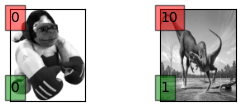

In [17]:
import matplotlib.pyplot as plt

def print_imagenes(imgs, targets, desde, hasta):
    # configuramos el tamaño de las imágenes por pulgadas
    fig = plt.figure(figsize=(30, 24))
    fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

    for i in range(desde, hasta):
        # graficamos las imágenes en una matriz de 25x20
        p = fig.add_subplot(25, 20, i + 1, xticks=[], yticks=[])
        p.imshow(imgs[i], cmap="gray")

        # etiquetar imágenes con target e indice
        p.text(0, 14, str(targets[i]), bbox=dict(facecolor="red", alpha=0.5))
        p.text(0, 100, str(i), bbox=dict(facecolor="green", alpha=0.5))
    plt.show()

print_imagenes(df.iloc[:, :]["imagen"], df.iloc[:, :]["peligrosidad"], 0, 2)

## ENTRENAR VARIOS REGRESORES Y MEDIR SU DESEMPEÑO

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [19]:
# Preparar características del dataframe
df_pixels = df["imagen"].apply(lambda img: img.flatten())  # Aplana cada imagen
df_pixels = pd.DataFrame(df_pixels.tolist())  # Expandir en columnas
df_final = pd.concat([df["peligrosidad"], df_pixels], axis=1)  # Unir con la edad

y = df["peligrosidad"]
X = df_final.drop(columns=["peligrosidad"])  # Características (píxeles)

In [20]:
def resumen_resultado(
    y_train, y_train_predicho, y_test, y_test_predicho, nombre_modelo="modelo"
):
    rmse_train = mean_squared_error(y_train, y_train_predicho) ** 0.5
    rmse_test = mean_squared_error(y_test, y_test_predicho) ** 0.5
    print(f"RMSE en train de {nombre_modelo}: {rmse_train:.6f}")
    print(f"RMSE en test de {nombre_modelo}: {rmse_test:.6f}")
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.scatter(y_test, y_test, color="red", label="Valor real")
    plt.scatter(y_test, y_test_predicho, color="blue", label="Valor predicho")
    plt.xlabel("peligrosidad")
    plt.ylabel("peligrosidad predicha")
    plt.axvline()
    plt.axhline()
    plt.title(f"Valor-predicción en Test ({nombre_modelo})")
    plt.legend()

    plt.subplot(1, 2, 2)
    bar_width = 0.35
    bars1 = plt.bar(
        2 - bar_width / 2,
        rmse_train,
        width=bar_width,
        label="RMSE Train",
        color="royalblue",
    )
    bars2 = plt.bar(
        2 + bar_width / 2, rmse_test, width=bar_width, label="RMSE Test", color="tomato"
    )

    # Anotar valores encima de las barras
    for bars in [bars1, bars2]:
        for bar in bars:
            yval = bar.get_height()
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                yval,
                f"{yval:.2f}",
                ha="center",
                va="bottom",
                fontsize=8,
            )

    plt.ylabel("RMSE")
    plt.title("RMSE en train y test")
    plt.legend()
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()

---

## ENTREGA 9:
### a) Añade a la carpeta compartida tus 10 fotografías con el formato indicado.
Ya están añadidas.

### b) Adapta el código propuesto, lo entregas y lo ejecutas.


In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import (
    BaggingRegressor,
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
)

semilla = 546
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=semilla)

escalador = StandardScaler()
X_train = escalador.fit_transform(X_train)
X_test = escalador.transform(X_test)

### c) Entrenas y pruebas el modelo SVR.

RMSE en train de SVR: 0.272374
RMSE en test de SVR: 3.502542


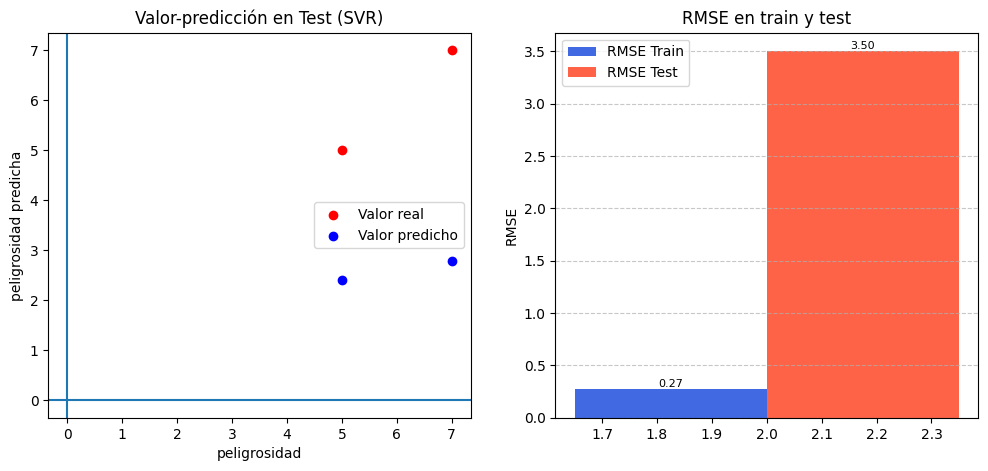

In [22]:
# SVR
svr = SVR(C=10, epsilon=0.1, kernel="rbf")
svr.fit(X_train, y_train)
resumen_resultado(y_train, svr.predict(X_train), y_test, svr.predict(X_test), "SVR")

### d) Entrenas y pruebas el modelo DecisionTreeRegressor.

RMSE en train de DecisionTreeRegressor: 2.891258
RMSE en test de DecisionTreeRegressor: 3.043949


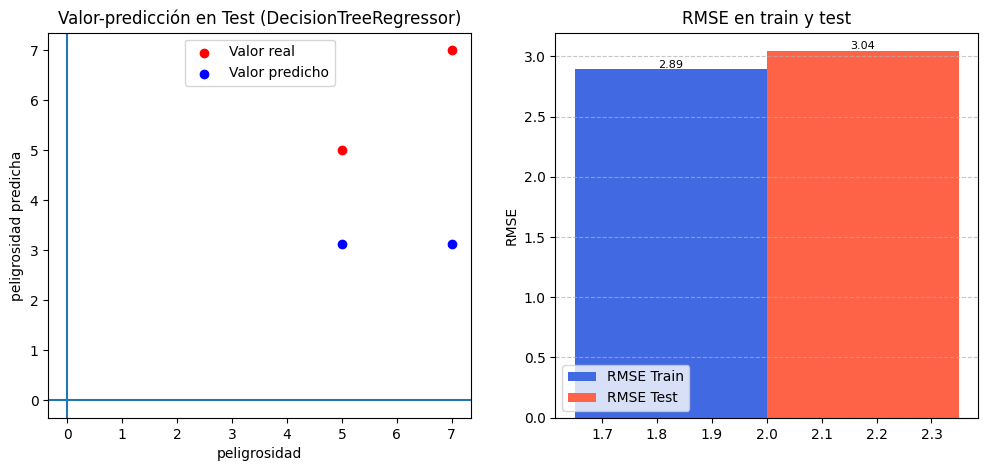

In [23]:
# DecisionTreeRegressor
arbol = DecisionTreeRegressor(max_depth=8, min_samples_split=10, random_state=semilla)
arbol.fit(X_train, y_train)
resumen_resultado(y_train, arbol.predict(X_train), y_test, arbol.predict(X_test), "DecisionTreeRegressor")

### e) Entrenas y pruebas el modelo KneighborsRegressor.

RMSE en train de KNeighborsRegressor: 0.000000
RMSE en test de KNeighborsRegressor: 2.595838


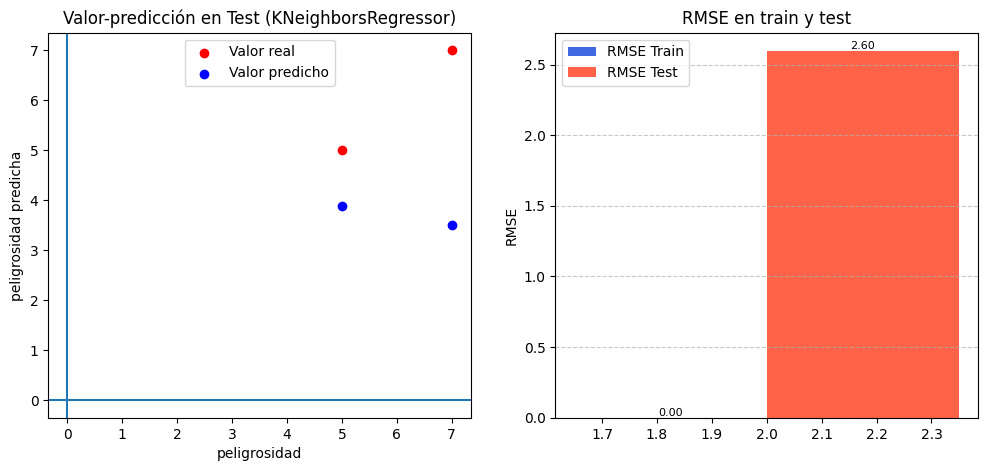

In [24]:
# KNeighborsRegressor
knn = KNeighborsRegressor(n_neighbors=5, weights="distance")
knn.fit(X_train, y_train)
resumen_resultado(y_train, knn.predict(X_train), y_test, knn.predict(X_test), "KNeighborsRegressor")

### f) Entrenas y pruebas el modelo BaggingRegressor.

RMSE en train de BaggingRegressor: 1.684132
RMSE en test de BaggingRegressor: 1.925097


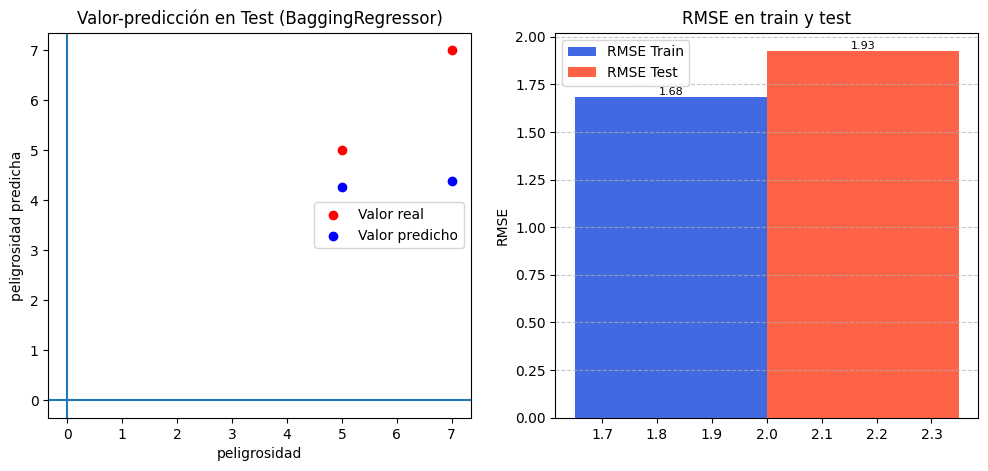

In [25]:
# BaggingRegressor
bagging = BaggingRegressor(n_estimators=50, max_samples=0.8, random_state=semilla)
bagging.fit(X_train, y_train)
resumen_resultado(y_train, bagging.predict(X_train), y_test, bagging.predict(X_test), "BaggingRegressor")

### g) Entrenas y pruebas el modelo RandomForestRegressor.

RMSE en train de RandomForestRegressor: 2.891311
RMSE en test de RandomForestRegressor: 3.060483


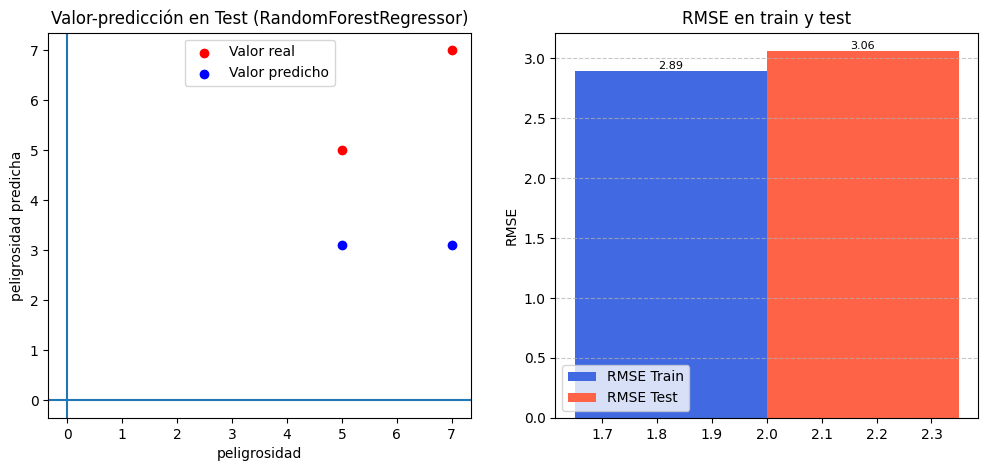

In [26]:
# RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=semilla)
rf.fit(X_train, y_train)
resumen_resultado(y_train, rf.predict(X_train), y_test, rf.predict(X_test), "RandomForestRegressor")

### h) Entrenas y pruebas el modelo AdaBoostRegressor.


RMSE en train de AdaBoostRegressor: 0.000000
RMSE en test de AdaBoostRegressor: 3.162278


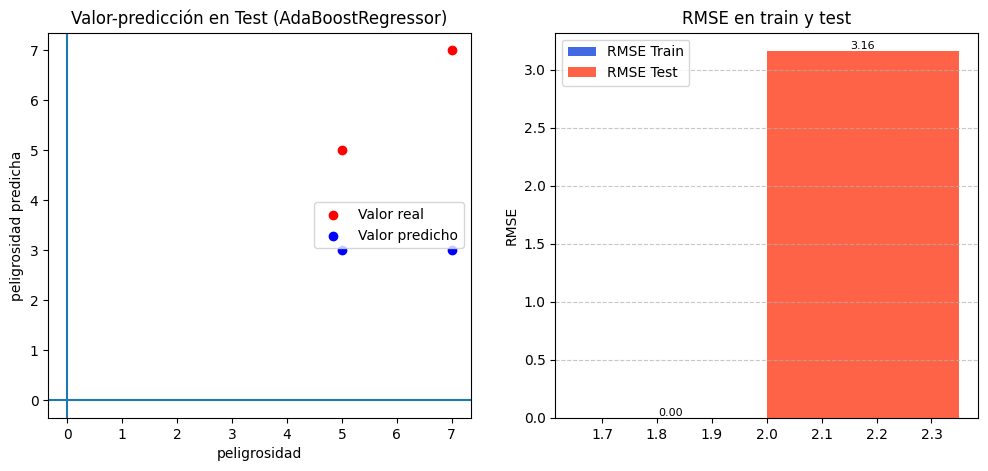

In [27]:
# AdaBoostRegressor
ada = AdaBoostRegressor(n_estimators=100, learning_rate=0.5, random_state=semilla)
ada.fit(X_train, y_train)
resumen_resultado(y_train, ada.predict(X_train), y_test, ada.predict(X_test), "AdaBoostRegressor")

### i) Entrenas y pruebas el modelo GradientBoostingRegressor.

RMSE en train de GradientBoostingRegressor: 0.000000
RMSE en test de GradientBoostingRegressor: 3.261672


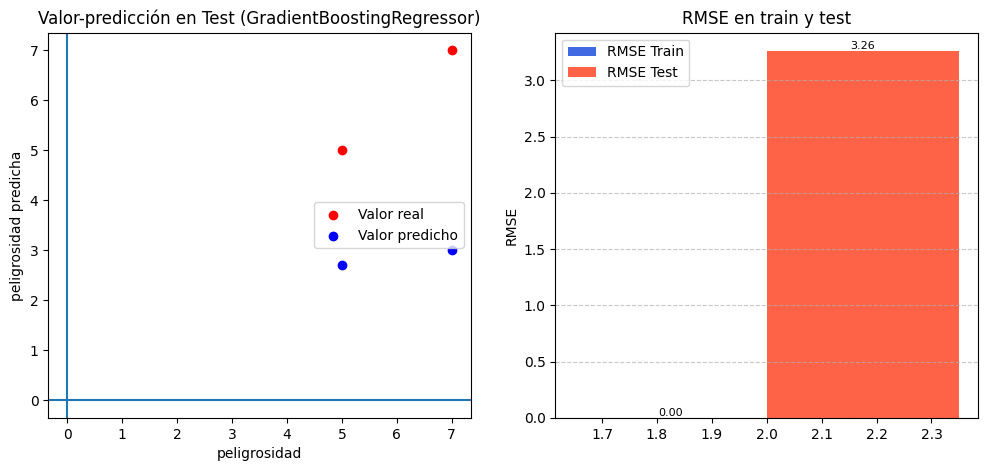

In [28]:
# GradientBoostingRegressor
gbr = GradientBoostingRegressor(n_estimators=150, learning_rate=0.1, max_depth=4, random_state=semilla)
gbr.fit(X_train, y_train)
resumen_resultado(y_train, gbr.predict(X_train), y_test, gbr.predict(X_test), "GradientBoostingRegressor")

### j) Comenta en cada uno de ellos los ajustes de hiperparámetros que has intentado para evitar que tengan underfitting o bien overfitting. Si no consigues solucionarlo deja la mejor configuración.
- **SVR**: el hiperparámetro C alto reduce el sesgo. El kernel RBF captura no linealidades.
- **DecisionTree**: controlo el sobreajuste limitando la profundidad (max_depth=8) y el mínimo de muestras por división (min_samples_split).
- **KNN**: he elegido (n_neighbors=5) para evitar ruido. Con (weights="distance") mejora la predicción con vecinos más cercanos.
- **Bagging**: un mayor número de estimadores y muestras aleatorias mejora la estabilidad.
- **RandomForest**: limito la profundidad y el número mínimo de muestras por hoja para regularizar.
- **AdaBoost**: disminuyo (learning_rate) para suavizar el aprendizaje y reducir la varianza.
- **GradientBoosting**: utilizar un (learning_rate) bajo, más árboles y profundidad limitada asgura que el "sesgo-varianza" esté bien ajustado.